In [58]:
from dataclasses import dataclass, Field

import pymc_marketing as pm_mrk 
from pymc_marketing.mmm import HSGP, WeeklyFourier, HSGPPeriodic, YearlyFourier
from pymc_marketing.prior import Prior
import pymc as pm
import numpy as np
import xarray as xr 
import matplotlib.pyplot as plt
import pandas as pd
import pytensor.tensor as pt

In [59]:
# Define the model for search clicks
n_days = 400 # Number of time points (days)
n_geos = 10  # Number of geos
# Generate example data
np.random.seed(42)
date = pd.date_range('2020-01-01', periods=n_days, freq='D')
time = xr.DataArray(np.arange(n_days), coords={'date': date}, dims=['date'])
geos = ['geo_' + str(i) for i in range(n_geos)]
lam_offset = xr.DataArray(np.random.normal(size=n_geos)*100, coords={'geo': np.arange(n_geos)}, dims=['geo'])

lam = 300 + 50 * np.sin(2 * np.pi * time / 7) + (150 * np.sin(2 * np.pi * time / 365) - 50 * np.sin(4 * np.pi * time / 365))*np.exp(lam_offset*.001) + lam_offset + 20*np.random.random(size=(n_days, n_geos)) # Varies over time
search_volume = xr.DataArray(np.random.poisson(lam=lam), coords={'date': date, 'geo': geos}, dims=['date', 'geo'])  # Daily search volume
impression_rate = 0.7 + 0.1 * np.sin(np.pi * 8 * time / 365) + 0.1 * np.sin(np.pi * 4 * time / 365) + 0 * lam_offset# Varies over time
impressions = xr.DataArray(np.random.binomial(search_volume, impression_rate), coords={'date': date, 'geo': geos}, dims=['date', 'geo'])  # Impressions from search volume
click_rate = 0.2 + 0.05 * np.cos(np.pi*2*time / 7) + .1 * np.sin(np.pi*2*time/365) + 0 * lam_offset # Varies over time
observed_clicks = xr.DataArray(np.random.binomial(impressions, click_rate), coords={'date': date, 'geo': geos}, dims=['date', 'geo'])  # Clicks can only come from impressions

dayofyear = xr.DataArray(date.dayofyear.to_numpy(), coords={'date': date}, dims=['date'])

data = xr.Dataset({'search_volume': search_volume, 'impressions': impressions, 'observed_clicks': observed_clicks, 'dayofyear': dayofyear, 'time': time})

#data = pd.DataFrame({'date': date, 'search_volume': search_volume, 'impressions': impressions, 'observed_clicks': observed_clicks})

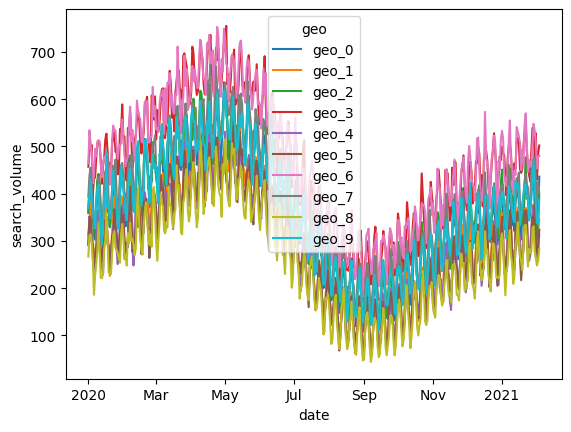

In [60]:
data.search_volume.plot.line(x='date', hue='geo');

Sampling: [var]


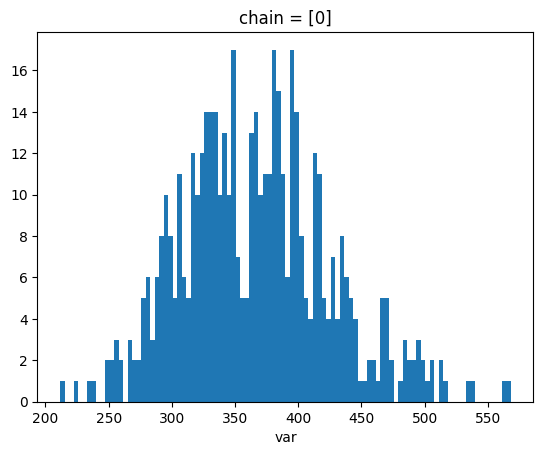

In [61]:
Prior("Gamma", alpha=36.5, beta=1/10).sample_prior()['var'].plot.hist(bins=100);

In [106]:
# long = HSGP(
#     m=40,
#     L=len(data['time'].values)*1.5,
#     ls=Prior('Gamma', alpha=2, beta=1/3),
#     eta=Prior("Exponential", lam=1),
#     dims=("date", "geo")
# )

long_periodic = HSGPPeriodic(
    m=40, 
    ls=Prior("Gamma", alpha=1, beta=1/5), 
    scale=Prior('Exponential', lam=1/100.), 
    dims=('date', 'geo'), 
    period=365)

yearly_seasonality = YearlyFourier(
    n_order=3, prefix='yearly_trend', dims=("date")
)
weekly_seasonality = WeeklyFourier(
    n_order=3, prefix='weekly_trend', dims=("date",)
)

train_growing_window_data = xr.Dataset({f'slice_{i}': data.isel(date=slice(0, i)).to_dataarray() for i in range(80, 400, 80)}|{'full':data.to_dataarray()})

train_data = data.isel(date=slice(0, 365))
test_data = data.isel(date=slice(35, None))

coords = {
    "date": data['date'].values,
    "geo": geos
}
def model_time_slice(modeling_window):
    long_periodic = HSGPPeriodic(
        m=40, 
        ls=Prior("Gamma", alpha=1, beta=1/5), 
        scale=Prior('Exponential', lam=1/100.), 
        dims=('date', 'geo'), 
        period=365)

    yearly_seasonality = YearlyFourier(
        n_order=3, prefix='yearly_trend', dims=("date")
    )
    weekly_seasonality = WeeklyFourier(
        n_order=3, prefix='weekly_trend', dims=("date",)
    )

    SEARCH_VOLUME = modeling_window.sel(variable='search_volume').dropna(dim='date')
    TIME = modeling_window.sel(variable='time').dropna(dim='date').mean(dim='geo')

    WINDOW_MEAN = SEARCH_VOLUME.mean(...).item()
    WINDOW_STD = SEARCH_VOLUME.std(...).item()
    coords = {
        "date": SEARCH_VOLUME['date'].values,
        "geo": SEARCH_VOLUME['geo'].values
    }
    with pm.Model(coords=coords) as model:
        time_data = pm.Data('time', TIME, dims='date')
        search_volume_data = pm.Data('search_volume_data', SEARCH_VOLUME, dims=('date', 'geo'))
        base_rate = pm.Normal('base_rate', mu=WINDOW_MEAN, sigma=WINDOW_STD)
        base_rate_sigma = pm.HalfNormal('base_rate_sigma', sigma=100)
        base_rate_geo = pm.Normal('base_rate_geo', mu=base_rate, sigma=base_rate_sigma, dims='geo')
    
        search_long_trend = long_periodic.register_data(time_data).create_variable("search_long_trend")
        #search_long_trend = pm.Deterministic('search_long_trend', yearly_seasonality.apply(time_data), dims="date")
        search_short_trend = pm.Deterministic("weekly_seasonality", weekly_seasonality.apply(time_data), dims="date")

        search_volume_lam = pt.softplus(search_short_trend[:, None] + search_long_trend + base_rate_geo)

        search_volume = pm.Deterministic("search_volume", search_volume_lam, dims=("date", "geo"))
    
        search_volume = pm.Poisson("search_volume_obs", mu=search_volume, observed=search_volume_data, dims=('date', 'geo'))
    
    return model

In [107]:
models = {name: model_time_slice(modeling_window) for name, modeling_window in train_growing_window_data.items()}
traces = {name: pm.sample(1000, tune=1000, model=model) for name, model in models.items()}
#posteriors = {name: pm.sample_posterior_predictive(traces[name], model=models[name], samples=1000) for name in models}

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [base_rate, base_rate_sigma, base_rate_geo, search_long_trend_scale, search_long_trend_ls, search_long_trend_hsgp_coefs_offset, weekly_trend_beta]
/Users/redam94/.local/share/uv/python/cpython-3.12.8-macos-aarch64-none/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Output()

/Users/redam94/.local/share/uv/python/cpython-3.12.8-macos-aarch64-none/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 75 seconds.
There were 52 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [base_rate, base_rate_sigma, base_rate_geo, search_long_trend_scale, search_long_trend_ls, search_long_trend_hsgp_coefs_offset, weekly_trend_beta]
/Users/redam94/.local/share/uv/python/cpython-3.12.8-macos-aarch64-none/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithr

Output()

...

/Users/redam94/.local/share/uv/python/cpython-3.12.8-macos-aarch64-none/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 528 seconds.
There were 15 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [base_rate, base_rate_sigma, base_rate_geo, search_long_trend_scale, search_long_trend_ls, search_long_trend_hsgp_coefs_offset, weekly_trend_beta]
/Users/redam94/.local/share/uv/python/cpython-3.12.8-macos-aarch64-none/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multith

Output()

/Users/redam94/.local/share/uv/python/cpython-3.12.8-macos-aarch64-none/lib/python3.12/multiprocessing/popen_fork.py:66: RuntimeWarning: os.fork() was called. os.fork() is incompatible with multithreaded code, and JAX is multithreaded, so this will likely lead to a deadlock.
  self.pid = os.fork()


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 405 seconds.
There were 15 divergences after tuning. Increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


In [108]:
traces['slice_80']

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data

In [109]:
data['date']

<xarray.DataArray 'date' (date: 400)> Size: 3kB
array(['2020-01-01T00:00:00.000000000', '2020-01-02T00:00:00.000000000',
       '2020-01-03T00:00:00.000000000', ..., '2021-02-01T00:00:00.000000000',
       '2021-02-02T00:00:00.000000000', '2021-02-03T00:00:00.000000000'],
      dtype='datetime64[ns]')
Coordinates:
  * date     (date) datetime64[ns] 3kB 2020-01-01 2020-01-02 ... 2021-02-03

In [110]:
posteriors = {}
for name in models:
    with models[name]:
        pm.set_data({'time': data['time'], 'search_volume_data':data['search_volume']}, coords={'date': data['date'].values})
        posteriors[name] = pm.sample_posterior_predictive(traces[name], extend_inferencedata=False)

Sampling: [search_volume_obs]


Output()

Sampling: [search_volume_obs]


Output()

Sampling: [search_volume_obs]


Output()

Sampling: [search_volume_obs]


Output()

Sampling: [search_volume_obs]


Output()

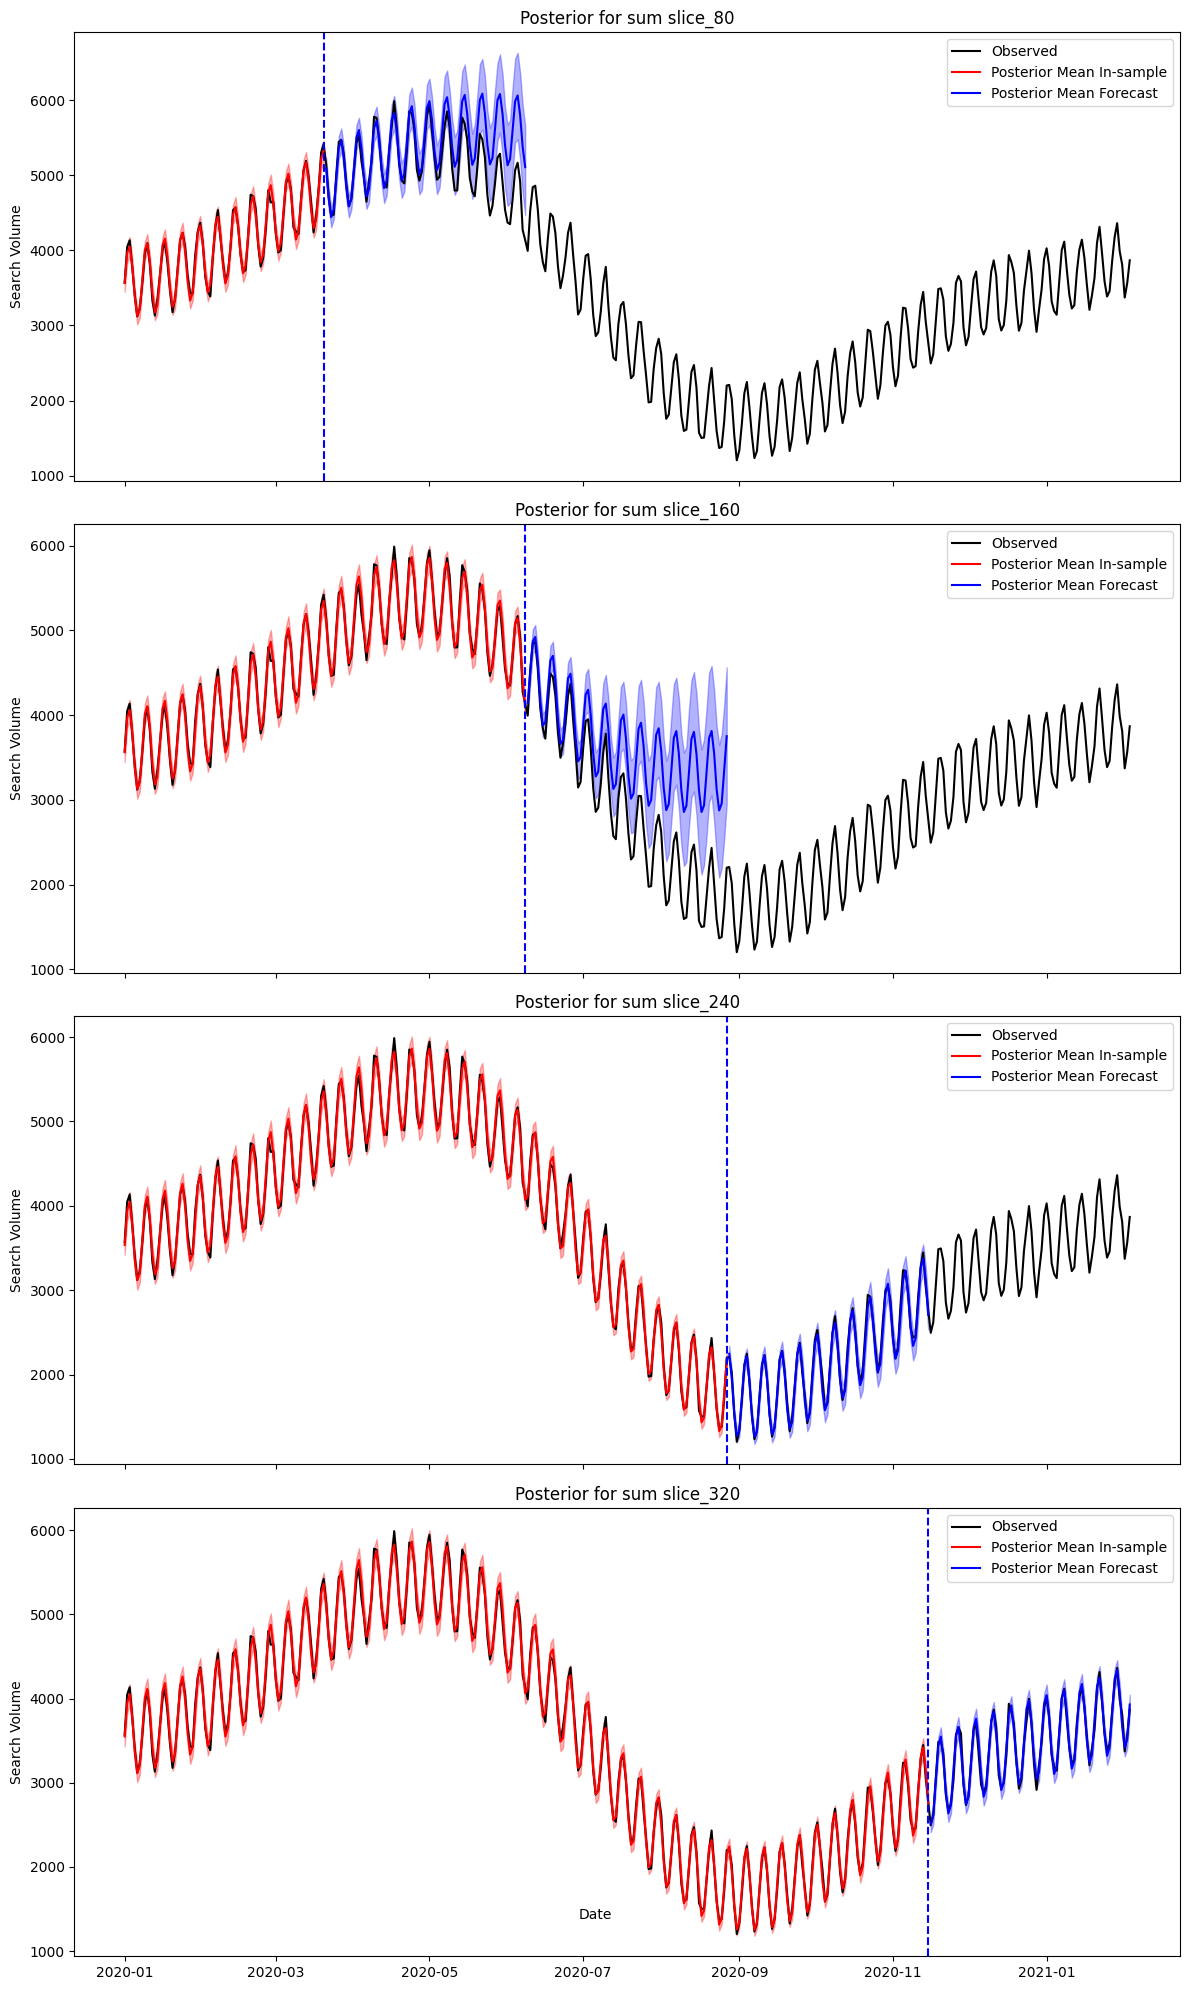

In [132]:
fig, axes = plt.subplots(len(posteriors)-1, 1, figsize=(12, 4*len(posteriors)), sharex=True)

GEO = 'sum'
# If there's only one slice, axes won't be an array
if len(posteriors) == 1:
    axes = [axes]

for i, (slice_name, posterior) in enumerate(posteriors.items()):
    if slice_name == 'full':
        continue

    ax = axes[i]
    
    # Get the observed data
    if GEO == 'sum':
        observed = data['search_volume'].sum(dim='geo')
        slice_len = train_growing_window_data[slice_name].dropna(dim='date').sum(dim='geo').sel(variable="search_volume").shape[0]
        posterior_mean = posterior.posterior_predictive.search_volume_obs.sum('geo').mean(dim=('chain', 'draw')).isel(date=slice(slice_len+80))
        posterior_hdi = pm.hdi(posterior.posterior_predictive.search_volume_obs.sum(dim='geo'))['search_volume_obs'].isel(date=slice(slice_len+80))
    else:
        observed = data['search_volume'].sel(geo=GEO)
        slice_len = train_growing_window_data[slice_name].dropna(dim='date').sel(variable="search_volume", geo=GEO).shape[0]
        # Get the posterior mean and HDI
        posterior_mean = posterior.posterior_predictive.search_volume_obs.mean(dim=('chain', 'draw')).sel(geo=GEO).isel(date=slice(slice_len+80))
        posterior_hdi = pm.hdi(posterior.posterior_predictive.search_volume_obs.sel(geo=GEO))['search_volume_obs'].isel(date=slice(slice_len+80))
    
    posterior_mean_insample = posterior_mean.isel(date=slice(0,slice_len))
    posterior_hdi_insample = posterior_hdi.isel(date=slice(0,slice_len))
    posterior_mean_oos = posterior_mean.isel(date=slice(slice_len, None))
    posterior_hdi_oos = posterior_hdi.isel(date=slice(slice_len, None))

    # Plot the data
    ax.plot(data['date'], observed, 'k-', label='Observed')
    ax.plot(posterior_mean_insample.date, posterior_mean_insample, 'r-', label='Posterior Mean In-sample')
    ax.plot(posterior_mean_oos.date, posterior_mean_oos, 'b-', label='Posterior Mean Forecast')

    
    # Plot the HDI
    ax.fill_between(
        posterior_hdi_insample.date.values, 
        posterior_hdi_insample.sel(hdi='lower'), 
        posterior_hdi_insample.sel(hdi='higher'), 
        color='r', alpha=0.3
    )
    # Plot the HDI
    ax.fill_between(
        posterior_hdi_oos.date.values, 
        posterior_hdi_oos.sel(hdi='lower'), 
        posterior_hdi_oos.sel(hdi='higher'), 
        color='b', alpha=0.3
    )
    
    # Add slice data boundary line if it's not the full dataset
    if slice_name != 'full':
        slice_size = int(slice_name.split('_')[1])
        ax.axvline(data['date'].values[slice_size-1], color='blue', linestyle='--')
        
    # Add title and labels
    ax.set_title(f'Posterior for {GEO} {slice_name}')
    ax.set_ylabel('Search Volume')
    ax.legend()

# Add common x-label
fig.text(0.5, 0.04, 'Date', ha='center', va='center')
fig.tight_layout()
plt.show()

In [658]:
train_growing_window_data.slice_1.sel(variable='search_volume')

<xarray.DataArray 'slice_1' (date: 400, geo: 10)> Size: 32kB
array([[361., 314., 359., ..., 394., 267., 370.],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       ...,
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan],
       [ nan,  nan,  nan, ...,  nan,  nan,  nan]])
Coordinates:
  * date      (date) datetime64[ns] 3kB 2020-01-01 2020-01-02 ... 2021-02-03
  * geo       (geo) <U5 200B 'geo_0' 'geo_1' 'geo_2' ... 'geo_7' 'geo_8' 'geo_9'
    variable  <U13 52B 'search_volume'

In [ ]:
with model:
    idata = pm.sample_prior_predictive(random_seed=rng)
    trace = pm.sample(1000, tune=1000, nuts_sampler='numpyro')

In [635]:
with model:
    posterior = pm.sample_posterior_predictive(trace, random_seed=rng)
    

Sampling: [search_volume_obs]


Output()

In [636]:
max(train_data.date.values).__str__()

'2020-12-30T00:00:00.000000000'

In [637]:
with model:
    pm.set_data(
        {'time': test_data['time'].values}, 
        coords={'date': test_data['date'].values, 'geo': geos})
    posterior_new = pm.sample_posterior_predictive(trace, random_seed=rng)

Sampling: [search_volume_obs]


Output()

In [638]:
test_data['date'].shape

(365,)

In [639]:
data['date'].max()

<xarray.DataArray 'date' ()> Size: 8B
array('2021-02-03T00:00:00.000000000', dtype='datetime64[ns]')

In [640]:
train_data['date'].max()

<xarray.DataArray 'date' ()> Size: 8B
array('2020-12-30T00:00:00.000000000', dtype='datetime64[ns]')

In [641]:
posterior_new.sel(date=slice('2020-12-31', None));

In [642]:
posterior_train_mean = posterior.posterior_predictive['search_volume_obs'].mean(dim=('chain', 'draw'))
posterior_train_hdi = pm.hdi(posterior.posterior_predictive['search_volume_obs'], .95).search_volume_obs

posterior_test_mean = posterior_new.sel(date=slice('2020-12-31', None)).posterior_predictive['search_volume_obs'].mean(dim=('chain', 'draw'))
posterior_test_hdi = pm.hdi(posterior_new.sel(date=slice('2020-12-31', None)).posterior_predictive['search_volume_obs'], .95).search_volume_obs

total_posterior_train_mean = posterior.posterior_predictive['search_volume_obs'].sum(dim='geo').mean(dim=('chain', 'draw'))
total_posterior_train_hdi = pm.hdi(posterior.posterior_predictive['search_volume_obs'].sum(dim='geo')).search_volume_obs

total_posterior_test_mean = posterior_new.sel(date=slice('2020-12-31', None)).posterior_predictive['search_volume_obs'].sum(dim='geo').mean(dim=('chain', 'draw'))
total_posterior_test_hdi = pm.hdi(posterior_new.sel(date=slice('2020-12-31', None)).posterior_predictive['search_volume_obs'].sum(dim='geo')).search_volume_obs

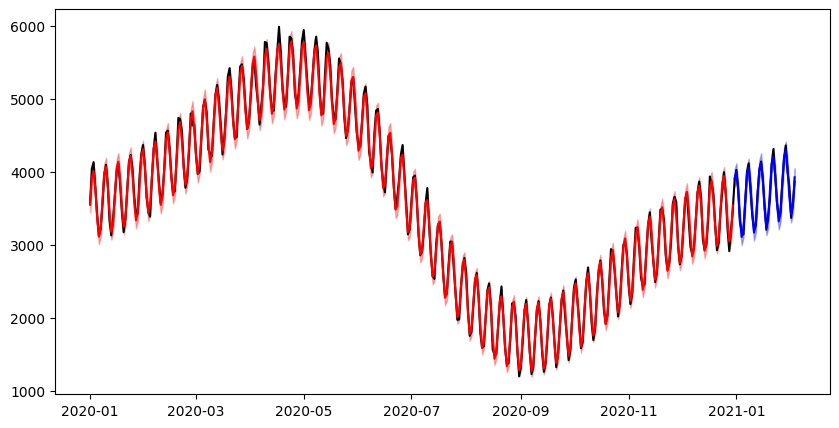

In [643]:
plt.figure(figsize=(10, 5))
plt.plot(data['date'], data['search_volume'].sum(dim='geo'), label='Observed', c='k')
plt.plot(train_data['date'], total_posterior_train_mean, label='Posterior', c='r')
plt.fill_between(
    total_posterior_train_hdi.date.values, total_posterior_train_hdi.sel(hdi='lower').values, 
    total_posterior_train_hdi.sel(hdi='higher').values, 
    color='r', alpha=0.3)
plt.plot(total_posterior_test_mean.date.values, total_posterior_test_mean, label='Posterior', c='b')
plt.fill_between(
    total_posterior_test_hdi.date.values, total_posterior_test_hdi.sel(hdi='lower').values, 
    total_posterior_test_hdi.sel(hdi='higher').values, color='b', alpha=0.3)


In [644]:
GEO = 'geo_0'
def plot_geo(geo=GEO):
    fig = plt.figure(figsize=(10, 5))
    plt.plot(data['date'], data['search_volume'].sel(geo=geo), label='Observed', c='k')
    plt.plot(train_data['date'], posterior_train_mean.sel(geo=geo), label='Posterior Mean Training', c='r')
    plt.fill_between(
        posterior_train_hdi.date.values, 
        posterior_train_hdi.sel(geo=geo, hdi='lower').values, 
        posterior_train_hdi.sel(geo=geo, hdi='higher').values, 
        color='r', alpha=0.3
        )
    plt.plot(posterior_test_mean.date.values, posterior_test_mean.sel(geo=geo), label='Posterior', c='b')
    plt.fill_between(
        posterior_test_hdi.date.values, 
        posterior_test_hdi.sel(geo=geo, hdi='lower').values, 
        posterior_test_hdi.sel(geo=geo, hdi='higher').values, 
        color='b', alpha=0.3
        )
    plt.legend()
    plt.title(f"Search Volume for {geo.replace("_", " ").capitalize()}")
    plt.xlabel("Date")
    plt.ylabel("Search Volume")
    return fig

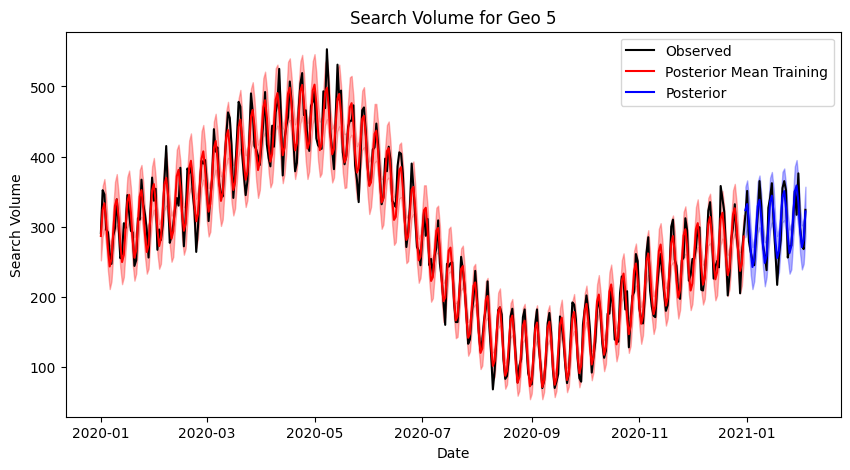

In [646]:
plot_geo('geo_5');

In [ ]:
DEFAULT_PRIORS = {
    'base_search_volume': Prior("Gamma", alpha=100, beta=1/5.0),
    'long_search_volume_trend': mmm.HSGP(
        m=40,
        L=len(data['time'].values)*1.5,
        ls=Prior('Gamma', alpha=2, beta=1/3),
        eta=Prior("Exponential", lam=1),
        dims=("date", "geo")
    ), 
    
}
@dataclass
class HierarchicalSearchModel:
    data: xr.Dataset = Field(..., metadata={'description': 'The data for the model'})
    prior: dict[str, Prior] = Field(default_factory=lambda : DEFAULT_PRIORS)

In [402]:
def gen_model(data, priors=None, coords=None):
    
    if coords is None:
        coords = {key: value.values for key, value in data.coords.items()}
    
    default_priors = {
        "base_demand": pm_mrk.prior.Prior('Normal', mu=300, sigma=300),
        "weekly_demand_seasonality_order": 4,
        "yearly_demand_seasonality_order": 4,
        'weekly_demand_seasonality': pm_mrk.prior.Prior('Normal', mu=0, sigma=50, dims=('weekly_demand')),
        'yearly_demand_seasonality': pm_mrk.prior.Prior('Normal', mu=0, sigma=150, dims=('yearly_demand')),
        'base_impressions': pm_mrk.prior.Prior('Normal', mu=0, sigma=1),
        'weekly_imp_seasonality_order': 4,
        'yearly_imp_seasonality_order': 4,
        'weekly_imp_seasonality': pm_mrk.prior.Prior('Normal', mu=0, sigma=1, dims=('weekly_imp')),
        'yearly_imp_seasonality': pm_mrk.prior.Prior('Normal', mu=0, sigma=1, dims=('yearly_imp')),
        'base_clicks': pm_mrk.prior.Prior('Normal', mu=0, sigma=1),
        'weekly_click_seasonality_order': 4,
        'yearly_click_seasonality_order': 4,
        'weekly_click_seasonality': pm_mrk.prior.Prior('Normal', mu=0, sigma=1, dims=('weekly_click')),
        'yearly_click_seasonality': pm_mrk.prior.Prior('Normal', mu=0, sigma=1, dims=('yearly_click')),
    }
    
    if priors is None:
        priors = default_priors
    else:
        priors = {**default_priors, **priors}

    date = data['date']
    dayofyear = data['dayofyear']

    weekly_demand_seasonality = pm_mrk.mmm.WeeklyFourier(n_order=priors['weekly_demand_seasonality_order'], prefix='weekly_demand', priors=priors['weekly_demand_seasonality'])
    yearly_demand_seasonality = pm_mrk.mmm.YearlyFourier(n_order=priors['yearly_demand_seasonality_order'], prefix='yearly_demand', priors=priors['yearly_demand_seasonality'])
    weekly_imp_seasonality = pm_mrk.mmm.WeeklyFourier(n_order=priors['weekly_imp_seasonality_order'], prefix='weekly_imp', priors=priors['weekly_imp_seasonality'])
    yearly_imp_seasonality = pm_mrk.mmm.YearlyFourier(n_order=priors['yearly_imp_seasonality_order'], prefix='yearly_imp', priors=priors['yearly_imp_seasonality'])
    weekly_click_seasonality = pm_mrk.mmm.WeeklyFourier(n_order=priors['weekly_click_seasonality_order'], prefix='weekly_click', priors=priors['weekly_click_seasonality'])
    yearly_click_seasonality = pm_mrk.mmm.YearlyFourier(n_order=priors['yearly_click_seasonality_order'], prefix='yearly_click', priors=priors['yearly_click_seasonality'])

    with pm.Model(coords=coords) as model:
        dayofyear = pm.Data('dayofyear', dayofyear, dims=('date',))
        
        base_demand = priors['base_demand'].create_variable('base_demand')
        weekly_demand_seasonality = weekly_demand_seasonality.apply(dayofyear)
        yearly_demand_seasonality = yearly_demand_seasonality.apply(dayofyear)
        demand = pm.Deterministic("demand", pt.math.softplus(base_demand + weekly_demand_seasonality + yearly_demand_seasonality))

        obs_demand = pm.Poisson('obs_demand', mu=demand, dims=tuple(data.dims.keys()))

        base_impressions = priors['base_impressions'].create_variable('base_impressions')
        weekly_imp_seasonality = weekly_imp_seasonality.apply(dayofyear)
        yearly_imp_seasonality = yearly_imp_seasonality.apply(dayofyear)
        impressions_rate = pm.Deterministic("impressions_rate", pm.math.invlogit(base_impressions + weekly_imp_seasonality + yearly_imp_seasonality))

        impressions = pm.Binomial('impressions', n=obs_demand, p=impressions_rate, dims=tuple(data.dims.keys()))

        base_clicks = priors['base_clicks'].create_variable('base_clicks')
        weekly_click_seasonality = weekly_click_seasonality.apply(dayofyear)
        yearly_click_seasonality =  yearly_click_seasonality.apply(dayofyear)
        click_rate = pm.Deterministic("click_rate", pm.math.invlogit(base_clicks + weekly_click_seasonality + yearly_click_seasonality))

        clicks = pm.Binomial('clicks', n=impressions, p=click_rate, dims=tuple(data.dims.keys()))

    return model



In [192]:
def train_model(data, samples, priors=None, sampler_kwargs=None):
    
    if sampler_kwargs is None:
        sampler_kwargs = {}
    model = gen_model(data, priors)
    with pm.observe(model, {'obs_demand': data['search_volume'].values, 'impressions': data['impressions'].values, 'clicks': data['observed_clicks'].values}):
        trace = pm.sample(samples, **sampler_kwargs)
    return model, trace

In [233]:
train_test_split = 0.9
n_train = int(n_days * train_test_split)
train_data = data.sel(date=slice(None, date[n_train]))
test_data = data.sel(date=slice(date[n_train], None))

# train_data.loc[5:10, 'clicks'] = np.nan
# train_data.loc[15:20, 'impressions'] = np.nan
# train_data.loc[25:30, 'obs_demand'] = np.nan

model, trace = train_model(train_data, 1000, sampler_kwargs={'nuts_sampler': 'nutpie'})

/var/folders/nw/92nd031j7p5d2bs8grpysp4w0000gn/T/ipykernel_11457/1001842126.py:47: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  obs_demand = pm.Poisson('obs_demand', mu=demand, dims=tuple(data.dims.keys()))
/var/folders/nw/92nd031j7p5d2bs8grpysp4w0000gn/T/ipykernel_11457/1001842126.py:54: FutureWarning: The return type of `Dataset.dims` will be changed to return a set of dimension names in future, in order to be more consistent with `DataArray.dims`. To access a mapping from dimension names to lengths, please use `Dataset.sizes`.
  impressions = pm.Binomial('impressions', n=obs_demand, p=impressions_rate, dims=tuple(data.dims.keys()))
/var/folders/nw/92nd031j7p5d2bs8grpysp4w0000gn/T/ipykernel_11457/1001842126.py:61: FutureWarning: The return type of `Dataset.dims` will be changed to ret

Progress,Draws,Divergences,Step Size,Gradients/Draw
,2000,0,0.09,63
,2000,0,0.11,319
,2000,0,0.10,63
,2000,0,0.10,31


In [234]:
def sample_posterior(model, trace, data=None):
    model_copy = pm.model.fgraph.clone_model(model)
    with model_copy:
        
        if data is not None:
            pm.set_data(
                {'dayofyear': data['dayofyear'].values}, coords={'date': data['date'].values})
            
        post_pred = pm.sample_posterior_predictive(trace)
    return post_pred


In [235]:
posterior_train = sample_posterior(model, trace)
posterior_test = sample_posterior(model, trace, data=test_data)

Sampling: [clicks, impressions, obs_demand]


Output()

/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/pymc/backends/arviz.py:66: UserWarning: Could not extract data from symbolic observation obs_demand
  warnings.warn(f"Could not extract data from symbolic observation {obs}")
/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/pymc/backends/arviz.py:66: UserWarning: Could not extract data from symbolic observation impressions
  warnings.warn(f"Could not extract data from symbolic observation {obs}")
/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/pymc/backends/arviz.py:66: UserWarning: Could not extract data from symbolic observation clicks
  warnings.warn(f"Could not extract data from symbolic observation {obs}")
Sampling: [clicks, impressions, obs_demand]


Output()

/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/pymc/backends/arviz.py:66: UserWarning: Could not extract data from symbolic observation obs_demand
  warnings.warn(f"Could not extract data from symbolic observation {obs}")
/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/pymc/backends/arviz.py:66: UserWarning: Could not extract data from symbolic observation impressions
  warnings.warn(f"Could not extract data from symbolic observation {obs}")
/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/pymc/backends/arviz.py:66: UserWarning: Could not extract data from symbolic observation clicks
  warnings.warn(f"Could not extract data from symbolic observation {obs}")


In [236]:
posterior_train.posterior_predictive['clicks'].mean(dim=('chain', 'draw')).values.shape

(361,)

In [237]:
trace

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data
	> constant_data

Warmup iterations saved (warmup_*).

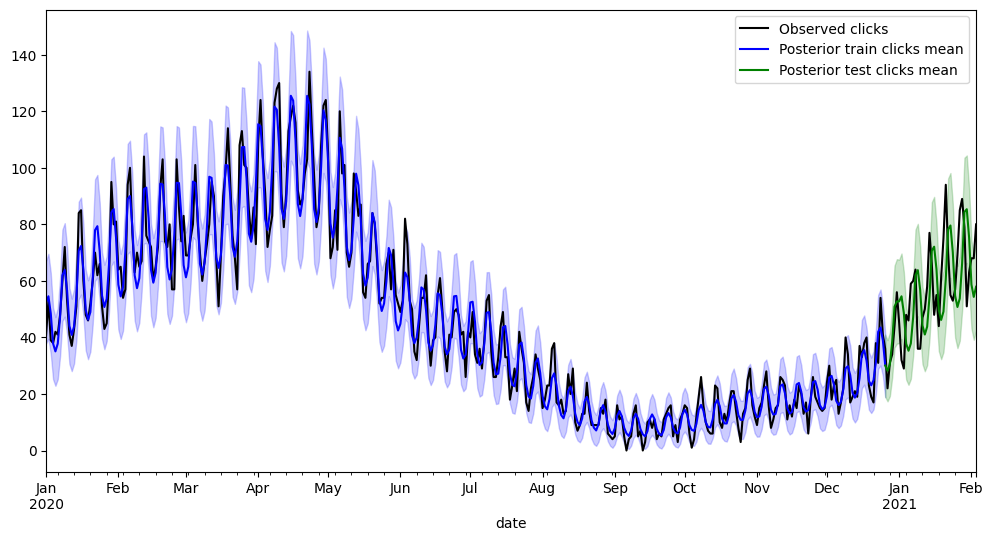

In [238]:
data_with_posterior = data.to_dataframe().reset_index().copy()
data_with_posterior['date'] = pd.to_datetime(data_with_posterior['date'])
data_with_posterior['posterior_train_clicks_mean'] = np.nan
data_with_posterior['posterior_train_clicks_std'] = np.nan
data_with_posterior.loc[:(n_train), 'posterior_train_clicks_mean'] = posterior_train.posterior_predictive['clicks'].mean(dim=('chain', 'draw')).values
data_with_posterior.loc[:(n_train), 'posterior_train_clicks_std'] = posterior_train.posterior_predictive['clicks'].std(dim=('chain', 'draw')).values
data_with_posterior['posterior_test_clicks_mean'] = np.nan
data_with_posterior['posterior_test_clicks_std'] = np.nan
data_with_posterior.loc[n_train:, 'posterior_test_clicks_mean'] = posterior_test.posterior_predictive['clicks'].mean(dim=('chain', 'draw')).values
data_with_posterior.loc[n_train:, 'posterior_test_clicks_std'] = posterior_test.posterior_predictive['clicks'].std(dim=('chain', 'draw')).values

fig, ax = plt.subplots(figsize=(12, 6))
data_with_posterior.plot(x='date', y='observed_clicks', ax=ax, label='Observed clicks', c='k')
data_with_posterior.plot(x='date', y='posterior_train_clicks_mean', ax=ax, label='Posterior train clicks mean', c='b')
data_with_posterior.plot(x='date', y='posterior_test_clicks_mean', ax=ax, label='Posterior test clicks mean', c='g')
plt.fill_between(
    data_with_posterior['date'].values, 
    data_with_posterior['posterior_train_clicks_mean'].values - 2 * data_with_posterior['posterior_train_clicks_std'].values, 
    data_with_posterior['posterior_train_clicks_mean'].values + 2 * data_with_posterior['posterior_train_clicks_std'].values, 
    alpha=0.2, color='b')
plt.fill_between(
    data_with_posterior['date'].values, 
    data_with_posterior['posterior_test_clicks_mean'].values - 2 * data_with_posterior['posterior_test_clicks_std'].values, 
    data_with_posterior['posterior_test_clicks_mean'].values + 2 * data_with_posterior['posterior_test_clicks_std'].values, 
    alpha=0.2, color='g')
plt.show()

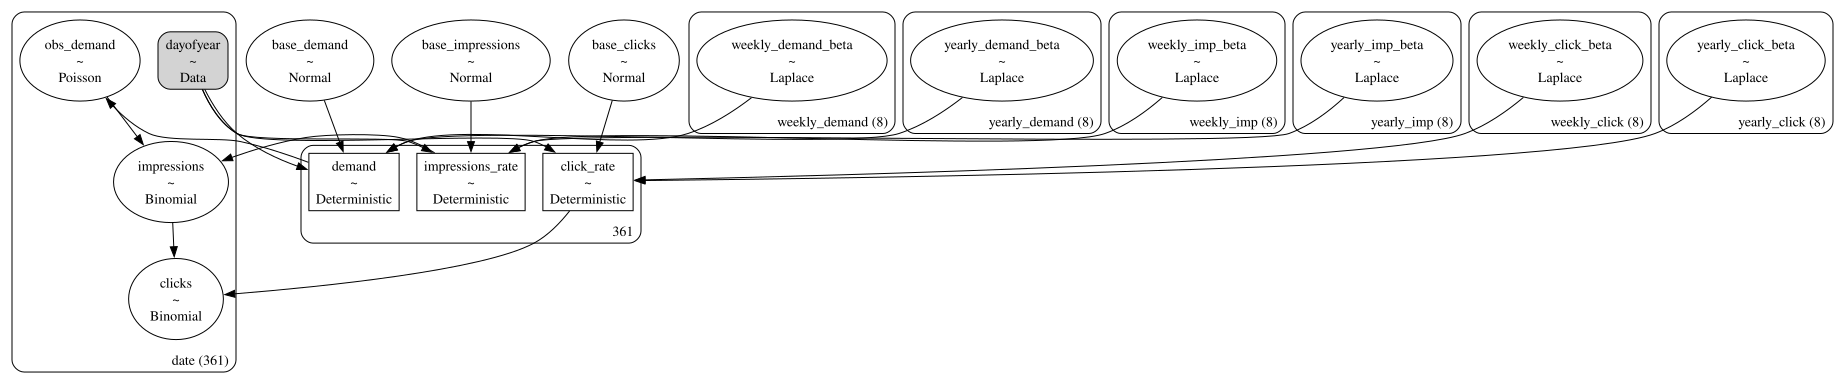

In [241]:
pm.model_to_graphviz(model)

In [240]:
with model:
    prior = pm.sample_prior_predictive()
    trace = pm.sample_posterior_predictive(trace, extend_inferencedata=True)

Sampling: [base_clicks, base_demand, base_impressions, clicks, impressions, obs_demand, weekly_click_beta, weekly_demand_beta, weekly_imp_beta, yearly_click_beta, yearly_demand_beta, yearly_imp_beta]
Sampling: [clicks, impressions, obs_demand]


Output()

/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/pymc/backends/arviz.py:66: UserWarning: Could not extract data from symbolic observation obs_demand
  warnings.warn(f"Could not extract data from symbolic observation {obs}")
/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/pymc/backends/arviz.py:66: UserWarning: Could not extract data from symbolic observation impressions
  warnings.warn(f"Could not extract data from symbolic observation {obs}")
/Users/redam94/Coding/Projects/search-click-prediction/.venv/lib/python3.12/site-packages/pymc/backends/arviz.py:66: UserWarning: Could not extract data from symbolic observation clicks
  warnings.warn(f"Could not extract data from symbolic observation {obs}")


Text(0.5, 1.0, 'Prior predictive draws for search volume')

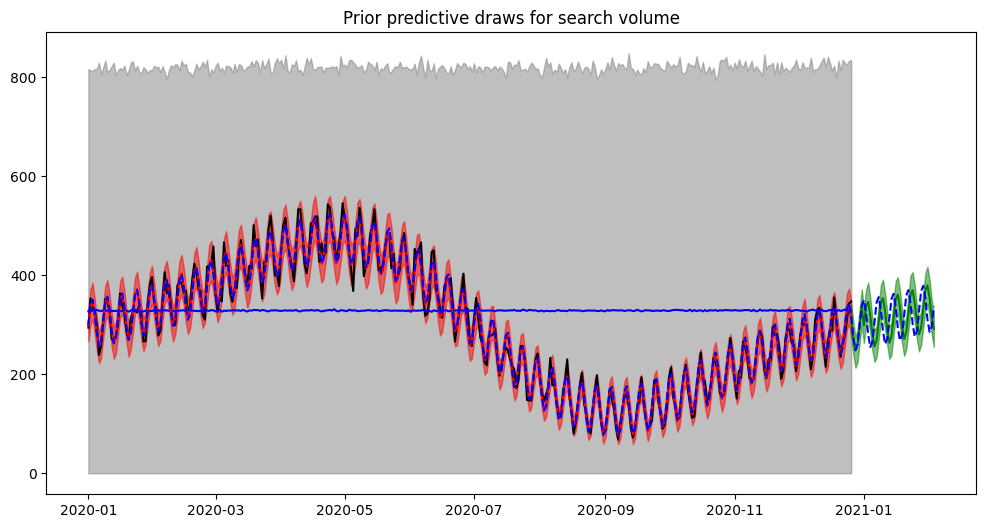

In [247]:
#prior.prior_predictive['search_volume']
plt.figure(figsize=(12, 6))
hdi_prior = pm.hdi(prior.prior['obs_demand'], hdi_prob=0.95)
date = train_data['date']
plt.fill_between(date, hdi_prior['obs_demand'].sel(hdi='lower'), hdi_prior['obs_demand'].sel(hdi='higher').values, color='gray', alpha=0.5)
plt.plot(date, train_data['search_volume'], color='black')
plt.plot(date, prior.prior['obs_demand'].mean(dim=('chain', 'draw')), color='blue')
plt.plot(date, trace.posterior_predictive['obs_demand'].mean(dim=('chain', 'draw')), color='red')
hdi_posterior = pm.hdi(trace.posterior_predictive['obs_demand'], hdi_prob=0.95)
plt.fill_between(date, hdi_posterior['obs_demand'].sel(hdi='lower'), hdi_posterior['obs_demand'].sel(hdi='higher'), color='red', alpha=0.5)
hdi_posterior_new = pm.hdi(posterior_test.posterior_predictive['obs_demand'], hdi_prob=0.95)
plt.plot(hdi_posterior_new['date'], posterior_test.posterior_predictive['obs_demand'].mean(dim=('draw', 'chain')), color='green')
plt.fill_between(hdi_posterior_new['date'], hdi_posterior_new['obs_demand'].sel(hdi='lower'), hdi_posterior_new['obs_demand'].sel(hdi='higher'), color='green', alpha=0.5)
plt.plot(lam.date, lam, color='blue', linestyle='--')
plt.title("Prior predictive draws for search volume")

Text(0.5, 1.0, 'Prior predictive draws for search impressions')

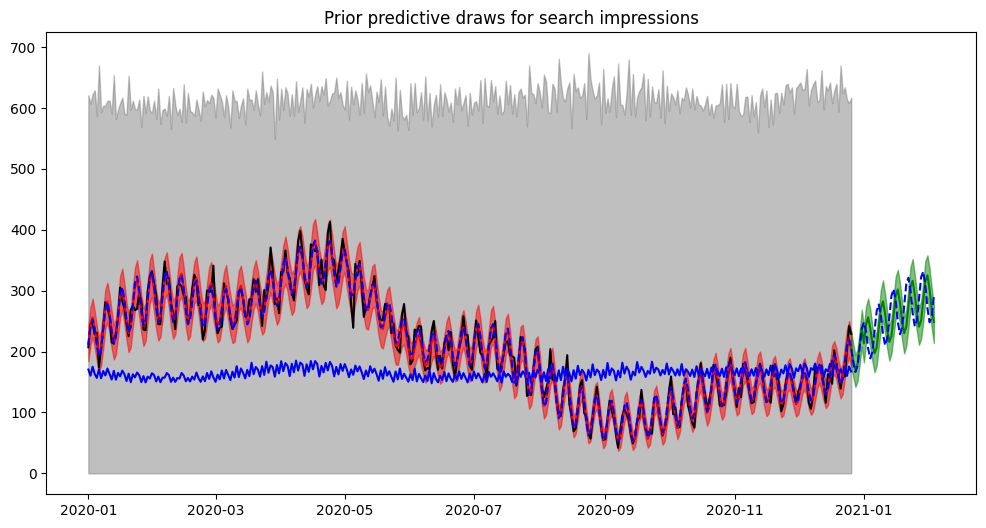

In [ ]:
plt.figure(figsize=(12, 6))
hdi_prior = pm.hdi(prior.prior['impressions'], hdi_prob=0.95)
plt.fill_between(date, hdi_prior['impressions'].sel(hdi='lower'), hdi_prior['impressions'].sel(hdi='higher').values, color='gray', alpha=0.5)
plt.plot(date, train_data['impressions'], color='black')
plt.plot(date, prior.prior['impressions'].mean(dim=('chain', 'draw')), color='blue')
plt.plot(date, trace.posterior_predictive['impressions'].mean(dim=('chain', 'draw')), color='red')
hdi_posterior = pm.hdi(trace.posterior_predictive['impressions'], hdi_prob=0.95)
plt.fill_between(date, hdi_posterior['impressions'].sel(hdi='lower'), hdi_posterior['impressions'].sel(hdi='higher'), color='red', alpha=0.5)
hdi_posterior_new = pm.hdi(posterior_test.posterior_predictive['impressions'], hdi_prob=0.95)
plt.plot(hdi_posterior_new['date'], posterior_test.posterior_predictive['impressions'].mean(dim=('draw', 'chain')), color='green')
plt.fill_between(hdi_posterior_new['date'], hdi_posterior_new['impressions'].sel(hdi='lower'), hdi_posterior_new['impressions'].sel(hdi='higher'), color='green', alpha=0.5)
plt.plot(data['date'], impression_rate*lam, color='blue', linestyle='--')
plt.title("Prior Vs Posterior Predictive draws for search impressions")

Text(0.5, 1.0, 'Prior predictive draws for search clicks')

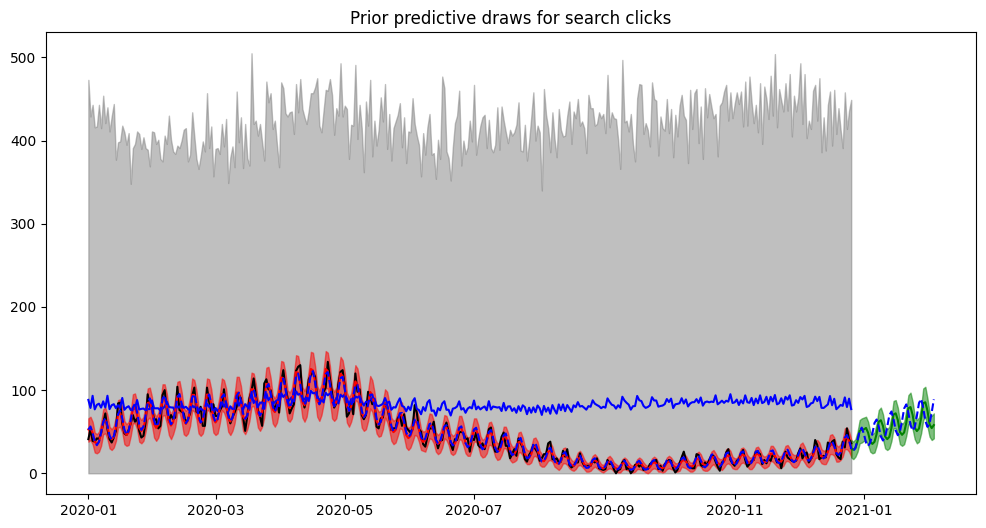

In [254]:
plt.figure(figsize=(12, 6))
hdi_prior = pm.hdi(prior.prior['clicks'], hdi_prob=0.95)
plt.fill_between(date, hdi_prior['clicks'].sel(hdi='lower'), hdi_prior['clicks'].sel(hdi='higher').values, color='gray', alpha=0.5)
plt.plot(date, train_data['observed_clicks'], color='black')
plt.plot(date, prior.prior['clicks'].mean(dim=('chain', 'draw')), color='blue')
plt.plot(date, trace.posterior_predictive['clicks'].mean(dim=('chain', 'draw')), color='red')
hdi_posterior = pm.hdi(trace.posterior_predictive['clicks'], hdi_prob=0.95)
plt.fill_between(date, hdi_posterior['clicks'].sel(hdi='lower'), hdi_posterior['clicks'].sel(hdi='higher'), color='red', alpha=0.5)
hdi_posterior_new = pm.hdi(posterior_test.posterior_predictive['clicks'], hdi_prob=0.95)
plt.plot(hdi_posterior_new['date'], posterior_test.posterior_predictive['clicks'].mean(dim=('draw', 'chain')), color='green')
plt.fill_between(hdi_posterior_new['date'], hdi_posterior_new['clicks'].sel(hdi='lower'), hdi_posterior_new['clicks'].sel(hdi='higher'), color='green', alpha=0.5)
plt.plot(data['date'], impression_rate*lam*click_rate, color='blue', linestyle='--')
plt.title("Prior predictive draws for search clicks")